# Canopy height statistics from terrestrial laser scanning (CAHST) — Python port of the published test-data pipeline

**Paper:** Friedli, Kirchgessner, Grieder, Liebisch, Mannale & Walter (2016),
*Terrestrial 3D laser scanning to track the increase in canopy height of both monocot and dicot crop species under field conditions.*
Plant Methods 12:9. DOI: [10.1186/s13007-016-0109-7](https://doi.org/10.1186/s13007-016-0109-7) (PMCID PMC4731982)

**Author software:** CAHST (MATLAB, compiled Windows standalone), https://sourceforge.net/projects/cahst4tls/
**Test data:** `CAHST_Testdata.zip` (same SourceForge project, soybean scans, ETH Eschikon 2014)

## Scope (partial demonstration) / スコープ（部分的な実演）
This notebook is an **ADAPTED PYTHON DEMONSTRATION** of the paper's canopy-height pipeline
(Methods section "Data processing and data analysis") applied to the **authors' own reduced test
dataset**: one soil scan + four soybean scans, rigidly stationed to the soil-scan coordinate
system, converted to a soil-relative height map with 5 mm pixels, and summarized per ROI with the
paper's FA_ALLPOINTS percentiles (P99 = canopy height).

> **AI-assisted Python port (English / 日本語):** The authors distributed CAHST only as a compiled
> Windows/MATLAB-2013b binary; no MATLAB source is included. This notebook was translated to
> Python from the paper's Methods and the CAHST manual (`CAHST_Manual.pdf`); **the authors did not
> provide this Colab implementation**. The executed example and listed checks were validated, but
> untested behavior is not guaranteed.
> **AIによるPython移植です**（原著者はWindows用コンパイル済みMATLABバイナリのみを公開）。検証済みの
> 例題実行結果を示しますが、未検証の挙動は保証されません。

**Not done here (GUI-only / out of scope):** xyz→mat conversion (test data ships as .mat),
interactive mouse ROI selection, FARO SCENE registration, xls export, season-long field campaigns.
**Runtime: CPU only** — the pipeline is point-cloud statistics; no GPU is used or needed.

## Run all — instructions / 実行手順
Select **Runtime → Change runtime type → CPU** (standard). Run all cells top to bottom.

Expected: ~20 MB download, well under 10 minutes total on the free CPU runtime / 無料CPUランタイムで数分。
All data is downloaded **inside Colab** from the authors' public SourceForge project; nothing is
read from private APIs or local disks. / データはすべてColab内でSourceForgeから取得します。

In [ ]:
import sys, zipfile, io, hashlib, urllib.request, os
import numpy as np
import h5py
import scipy
import scipy.ndimage as ndi
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

print('python', sys.version.split()[0])
print('numpy', np.__version__, '| scipy', scipy.__version__,
      '| matplotlib', matplotlib.__version__, '| pandas', pd.__version__)

python 3.13.15
numpy 2.1.3 | scipy 1.16.3 | matplotlib 3.10.0 | pandas 2.2.3


## Download the authors' test dataset / 著者公開テストデータの取得
`CAHST_Testdata.zip` (18.4 MB, SourceForge project `cahst4tls`, 2015-08-14) is fetched inside
Colab, its zip signature, member list and SHA-256 are verified before use.
/ テストデータをColab内でダウンロードし、ZIPシグネチャ・内容・SHA-256を検証します。

In [ ]:
URL = 'https://downloads.sourceforge.net/project/cahst4tls/CAHST_Testdata.zip'
ZIP = '/content/CAHST_Testdata.zip'
if not os.path.exists(ZIP):
    urllib.request.urlretrieve(URL, ZIP)

raw = open(ZIP, 'rb').read()
assert raw[:4] == b'PK\x03\x04', 'not a zip archive'
print('downloaded bytes:', len(raw))
print('sha256:', hashlib.sha256(raw).hexdigest())

zf = zipfile.ZipFile(io.BytesIO(raw))
names = zf.namelist()
print(f'{len(names)} members (expect 11: 5 .mat + 5 _refcoord.txt + 1 readme pdf):')
for i in zf.infolist():
    print(f'  {i.file_size:>10,}  {i.filename}')
zf.extractall('/content')
DATA = '/content/CAHST_Testdata'

downloaded bytes: 18373641
sha256: 2ebe8df2b468ff9e219ce6affa04a9c4b8b482bb32a7896ade39be4dd4bdf02d
11 members (expect 11: 5 .mat + 5 _refcoord.txt + 1 readme pdf):
   3,860,331  CAHST_Testdata/20140621_06_00_Soja_soil.mat
         234  CAHST_Testdata/20140621_06_00_Soja_soil_refcoord.txt
   4,125,504  CAHST_Testdata/20140621_14_43_Soja_Afternoon.mat
         233  CAHST_Testdata/20140621_14_43_Soja_Afternoon_refcoord.txt
   4,091,955  CAHST_Testdata/20140622_15_11_Soja_Afternoon.mat
         232  CAHST_Testdata/20140622_15_11_Soja_Afternoon_refcoord.txt
   3,255,189  CAHST_Testdata/20140716_14_49_Soja_Afternoon.mat
         217  CAHST_Testdata/20140716_14_49_Soja_Afternoon_refcoord.txt
   3,056,520  CAHST_Testdata/20140717_14_38_Soja_Afternoon.mat
         218  CAHST_Testdata/20140717_14_38_Soja_Afternoon_refcoord.txt
      31,820  CAHST_Testdata/readme_CAHST_Testdata.pdf


## Input files / 入力ファイル
Each scan is a MATLAB v7.3 (HDF5) file with variable `pos` (3 × N, float32, metres: x, y, z).
Each scan has a companion `_refcoord.txt` with the detected positions of the five fixed
ground-sphere targets (probe-verified in a prior diagnostic run).
/ スキャンはMATLAB v7.3形式（`pos`: 3×N float32, 単位m）。各スキャンには5球のターゲット座標
`_refcoord.txt`が対応します。

In [ ]:
def load_scan(stem):
    with h5py.File(f'{DATA}/{stem}.mat', 'r') as f:
        pos = np.asarray(f['pos'][()], dtype=np.float64)
    if pos.shape[0] != 3:
        pos = pos.T
    assert pos.shape[0] == 3
    return pos

def load_refcoord(stem):
    sph = {}
    with open(f'{DATA}/{stem}_refcoord.txt') as fh:
        for line in fh:
            parts = line.replace(':', ' ').split()
            if len(parts) == 5 and parts[0] == 'Sphere':   # 'Sphere k: x y z'
                sph[int(parts[1])] = np.array([float(v) for v in parts[2:]])
    return np.array([sph[k] for k in sorted(sph)])

SCANS = ['20140621_06_00_Soja_soil',
         '20140621_14_43_Soja_Afternoon',
         '20140622_15_11_Soja_Afternoon',
         '20140716_14_49_Soja_Afternoon',
         '20140717_14_38_Soja_Afternoon']

clouds = {s: load_scan(s) for s in SCANS}
refs   = {s: load_refcoord(s) for s in SCANS}
for s in SCANS:
    print(f'{s}: {clouds[s].shape[1]:>7,} points, x [{clouds[s][0].min():.2f}, {clouds[s][0].max():.2f}] '
          f'y [{clouds[s][1].min():.2f}, {clouds[s][1].max():.2f}] z [{clouds[s][2].min():.2f}, {clouds[s][2].max():.2f}] m')

20140621_06_00_Soja_soil: 397,642 points, x [-2.04, 2.76] y [-1.66, 3.18] z [38.68, 40.58] m
20140621_14_43_Soja_Afternoon: 451,522 points, x [-2.04, 2.76] y [-1.66, 3.17] z [38.69, 40.58] m
20140622_15_11_Soja_Afternoon: 453,958 points, x [-2.37, 2.52] y [-0.72, 4.19] z [26.11, 28.00] m
20140716_14_49_Soja_Afternoon: 352,413 points, x [-2.26, 2.61] y [-1.10, 3.81] z [-2.07, -0.17] m
20140717_14_38_Soja_Afternoon: 331,966 points, x [-2.28, 2.63] y [-0.71, 4.22] z [-3.46, -1.57] m


## Step 1 — Stationing (rigid registration to the soil-scan frame) / ステーショニング
Paper: *"Sphere coordinates of all scans ... were used to estimate the rigid coordinate
transformation for all point clouds to fixed coordinates"* (Methods; manual §3b; the CAHST binary
uses Taati's `estimateRigidTransform`). We estimate the same rigid transform (rotation R +
translation t, no scaling) by least squares on the five sphere correspondences — the closed-form
Kabsch solution with SVD, a standard equivalent of `estimateRigidTransform` for rigid motion.
The reference frame **CRef is the soil scan's own frame** (manual: first stationing line is 0).
/ 剛体変換（回転+並進）を5球対応点の最小二乗（Kabsch/SVD）で推定し、土壌スキャン座標系に揃えます。

In [ ]:
def kabsch_rigid(src, dst):
    # least-squares rigid transform (R, t) with src @ R.T + t ~= dst ; no scaling
    mu_s, mu_d = src.mean(0), dst.mean(0)
    H = (src - mu_s).T @ (dst - mu_d)
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1.0, 1.0, d])
    R = Vt.T @ D @ U.T
    t = mu_d - R @ mu_s
    return R, t

soil = SCANS[0]
stationed = {}
for s in SCANS:
    if s == soil:
        R, t = np.eye(3), np.zeros(3)
    else:
        R, t = kabsch_rigid(refs[s], refs[soil])
    res = (R @ refs[s].T).T + t - refs[soil]
    rmse = np.sqrt((res ** 2).sum(1)).mean()
    print(f'{s}: sphere RMSE after stationing = {rmse * 1000:.2f} mm')
    # transform 3 x N point cloud: (R @ pts).T + t, computed per column
    stationed[s] = (R @ clouds[s] + t[:, None])

20140621_06_00_Soja_soil: sphere RMSE after stationing = 0.00 mm
20140621_14_43_Soja_Afternoon: sphere RMSE after stationing = 1.69 mm
20140622_15_11_Soja_Afternoon: sphere RMSE after stationing = 1.69 mm
20140716_14_49_Soja_Afternoon: sphere RMSE after stationing = 1.66 mm
20140717_14_38_Soja_Afternoon: sphere RMSE after stationing = 1.21 mm


## Step 2 — Soil height map H_S (5 mm pixels) / 土壌高さマップ
Paper Methods: *"Generation of soil height as a 'height image' (H_S) with 5 mm pixel size ...
the height minimum was first determined on the pixel grid. Gaps were interpolated. The result
was median-filtered with a patch size of 21 cm."* — implemented literally: per-pixel **minimum z**
on a 5 mm grid, nearest-valid-pixel interpolation of gaps, 41 × 41 px (20.5 cm ≈ 21 cm) median
filter. / 5mmピクセルで各ピクセルの最小zを取り、欠損を補間し、21cm相当のメディアンフィルタを適用。

In [ ]:
PIX = 0.005          # 5 mm pixel, metres (paper)
MEDIAN_PATCH_CM = 21 # paper: median filter patch 21 cm

x, y, z = stationed[soil]
x0, x1 = x.min(), x.max(); y0, y1 = y.min(), y.max()
nx = int(np.ceil((x1 - x0) / PIX)); ny = int(np.ceil((y1 - y0) / PIX))
ix = ((x - x0) / PIX).astype(int); iy = ((y - y0) / PIX).astype(int)

grid = np.full((ny, nx), np.inf)
np.minimum.at(grid, (iy, ix), z)  # per-pixel height minimum (paper)
grid[np.isinf(grid)] = np.nan     # pixels without soil points

valid = ~np.isnan(grid)
print(f'soil grid {ny} x {nx} px ({ny*PIX:.2f} x {nx*PIX:.2f} m), '
      f'{valid.sum():,} filled / {grid.size:,} pixels ({valid.mean()*100:.0f} %)')

# gap interpolation: nearest valid pixel (paper: "gaps were interpolated")
ind = ndi.distance_transform_edt(~valid, return_indices=True, return_distances=False)
H_S = grid[tuple(ind)]

# median filter, 21 cm patch -> 41 px (0.205 m)
k = int(round(MEDIAN_PATCH_CM / 100 / PIX)); k += (k + 1) % 2
H_S = ndi.median_filter(H_S, size=k, mode='nearest')
print(f'median filter patch: {k} x {k} px = {k*PIX*100:.0f} cm')

soil grid 969 x 961 px (4.84 x 4.80 m), 266,563 filled / 931,209 pixels (29 %)


median filter patch: 43 x 43 px = 22 cm


Preview the soil height map (input soil scan → derived H_S) / 土壌高さマップの可視化。

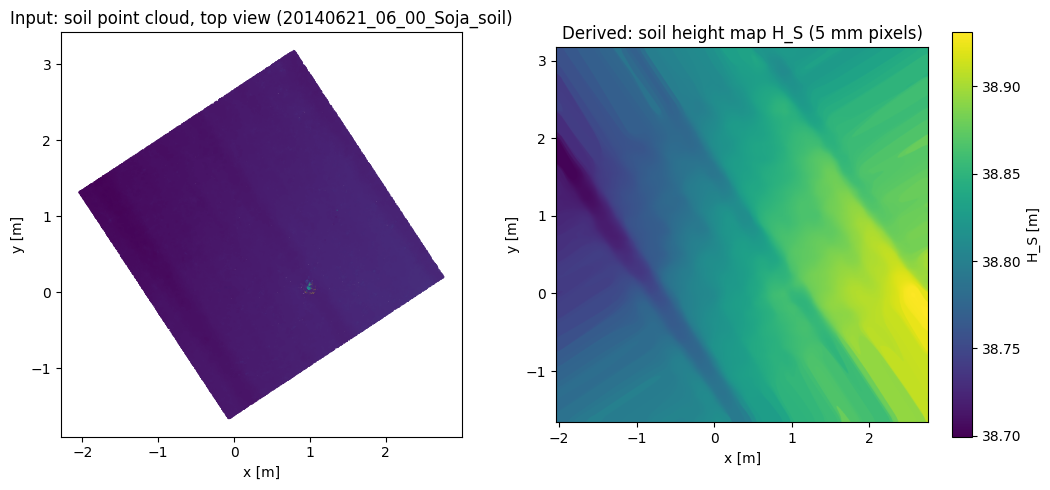

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
pts = stationed[soil]
ax[0].scatter(pts[0], pts[1], s=0.05, c=pts[2], cmap='viridis')
ax[0].set(title=f'Input: soil point cloud, top view ({soil})', xlabel='x [m]', ylabel='y [m]')
im = ax[1].imshow(H_S, extent=[x0, x1, y0, y1], origin='lower', cmap='viridis')
ax[1].set(title=f'Derived: soil height map H_S ({PIX*1000:.0f} mm pixels)', xlabel='x [m]', ylabel='y [m]')
plt.colorbar(im, ax=ax[1], label='H_S [m]')
for a_ in ax: a_.set_aspect('equal')
fig.tight_layout()
fig.savefig('/content/soil_height_map.png', dpi=120)
plt.show(); plt.close(fig)

## Step 3 — Soil-relative plant point heights / 土壌基準の相対高さ
Paper: *"Subtraction of soil level from each point of the point cloud using the appropriate entry
of H_S"* (projection along z) and manual config *"0.1 inf"* — points with relative height above
0.1 m are treated as plant points (paper: *"Points higher than 10 cm were regarded as 'plant
points'"*). / 各点からH_Sを差し引き、相対高さ0.1m超を植物点とします。

In [ ]:
def relative_heights(stem):
    pts = stationed[stem]
    ix = ((pts[0] - x0) / PIX).astype(int).clip(0, nx - 1)
    iy = ((pts[1] - y0) / PIX).astype(int).clip(0, ny - 1)
    h = pts[2] - H_S[iy, ix]                       # subtract soil level (paper)
    return pts, h

plant = {}
for s in SCANS[1:]:
    pts, h = relative_heights(s)
    mask = h > 0.10                                 # plant points above 0.1 m (paper/manual)
    plant[s] = (pts[:, mask], h[mask])
    print(f'{s}: {mask.sum():>7,} plant points of {h.size:,} '
          f'({mask.mean()*100:.1f} %), max rel. height {h.max():.2f} m')

20140621_14_43_Soja_Afternoon: 137,664 plant points of 451,522 (30.5 %), max rel. height 1.73 m
20140622_15_11_Soja_Afternoon: 233,457 plant points of 453,958 (51.4 %), max rel. height 1.79 m
20140716_14_49_Soja_Afternoon: 351,700 plant points of 352,413 (99.8 %), max rel. height 1.77 m
20140717_14_38_Soja_Afternoon: 331,548 plant points of 331,966 (99.9 %), max rel. height 1.78 m


## Step 4 — ROIs / 解析領域
CAHST selects ROIs interactively (manual §3c, GUI). Here two 1 m × 1 m square ROIs are defined
**programmatically** inside the scanned area — a documented adaptation of the GUI step.
/ CAHSTではROIをGUIで選択しますが、ここはプログラム的に1m×1mの矩形2つを定義します（明示した適応）。

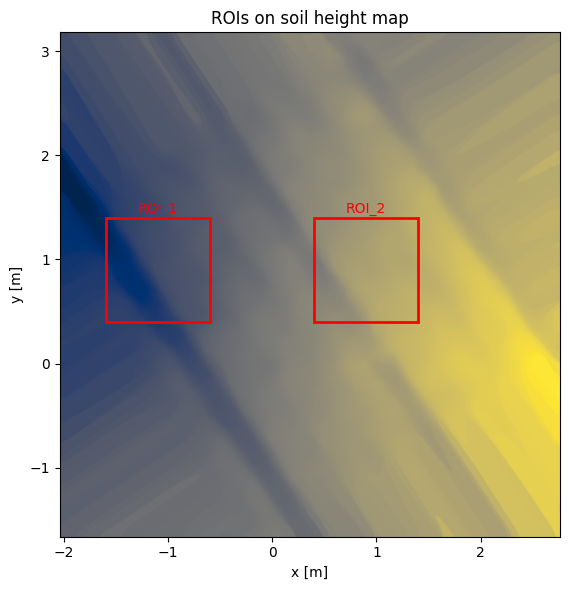

In [ ]:
ROIS = {'ROI_1': (-1.6, -0.6, 0.4, 1.4),   # (x0, x1, y0, y1) in metres, CRef frame
        'ROI_2': ( 0.4,  1.4, 0.4, 1.4)}

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(H_S, extent=[x0, x1, y0, y1], origin='lower', cmap='cividis')
import matplotlib.patches as mpatches
for name, (rx0, rx1, ry0, ry1) in ROIS.items():
    ax.add_patch(mpatches.Rectangle((rx0, ry0), rx1-rx0, ry1-ry0, fill=False, ec='red', lw=2))
    ax.text((rx0+rx1)/2, ry1+0.05, name, color='red', ha='center')
ax.set(title='ROIs on soil height map', xlabel='x [m]', ylabel='y [m]')
ax.set_aspect('equal')
fig.tight_layout(); fig.savefig('/content/roi_selection.png', dpi=120); plt.show(); plt.close(fig)

## Step 5 — FA_ALLPOINTS percentiles / 全点パーセンタイル（FA_ALLPOINTS）
Paper: FA_ALLPOINTS takes **every point** of the scan cloud within the ROI; P99 was found to
approximate canopy height best (wheat R² 0.99) and was used throughout the paper. Percentiles use
linear interpolation (MATLAB `prctile` default ≈ `numpy.percentile` default).
/ FA_ALLPOINTSはROI内の全点でパーセンタイルを計算します。論文ではP99がキャノピー高の最良指標。

In [ ]:
def roi_stats(stem):
    pts, h = plant[stem]
    rows = []
    for name, (rx0, rx1, ry0, ry1) in ROIS.items():
        m = (pts[0] >= rx0) & (pts[0] < rx1) & (pts[1] >= ry0) & (pts[1] < ry1)
        hr = h[m]
        if hr.size == 0:   # guard: ROI without plant points in this scan
            rows.append({'scan': stem, 'roi': name, 'n_plant_points': 0,
                         'P90_m': np.nan, 'P95_m': np.nan, 'P99_m': np.nan, 'P100_m': np.nan})
        else:
            rows.append({'scan': stem, 'roi': name, 'n_plant_points': int(m.sum()),
                         'P90_m': np.percentile(hr, 90), 'P95_m': np.percentile(hr, 95),
                         'P99_m': np.percentile(hr, 99), 'P100_m': hr.max()})
    return rows

records = [r for s in SCANS[1:] for r in roi_stats(s)]
df = pd.DataFrame(records)
df['date'] = df['scan'].str[:8]
df['canopy_height_P99_m'] = df['P99_m']
print(df[['scan', 'roi', 'n_plant_points', 'P90_m', 'P95_m', 'P99_m', 'P100_m']]
      .to_string(index=False, float_format=lambda v: f'{v:.3f}'))
df.to_csv('/content/cahst_fa_allpoints_stats.csv', index=False)
print('saved /content/cahst_fa_allpoints_stats.csv')

                         scan   roi  n_plant_points  P90_m  P95_m  P99_m  P100_m
20140621_14_43_Soja_Afternoon ROI_1           10205  0.187  0.198  0.225   0.257
20140621_14_43_Soja_Afternoon ROI_2           13332  0.177  0.188  0.211   0.246
20140622_15_11_Soja_Afternoon ROI_1           22126  0.263  0.277  0.299   0.780
20140622_15_11_Soja_Afternoon ROI_2            4945  0.247  0.264  0.285   0.306
20140716_14_49_Soja_Afternoon ROI_1           29879  0.664  0.679  0.705   0.744
20140716_14_49_Soja_Afternoon ROI_2           25704  0.587  0.598  0.619   0.671
20140717_14_38_Soja_Afternoon ROI_1           26701  0.688  0.701  0.724   0.790
20140717_14_38_Soja_Afternoon ROI_2            7324  0.637  0.656  0.700   0.738
saved /content/cahst_fa_allpoints_stats.csv


## Canopy height over time (P99, FA_ALLPOINTS) / P99キャノピー高の時間変化
An additional visualization created for this notebook (not an author figure): P99 canopy height
per ROI across the four soybean scan dates — the paper's core quantity (canopy height growth).
/ 本ノートブック用の追加可視化です（著者の図ではありません）。4日間のP99キャノピー高。

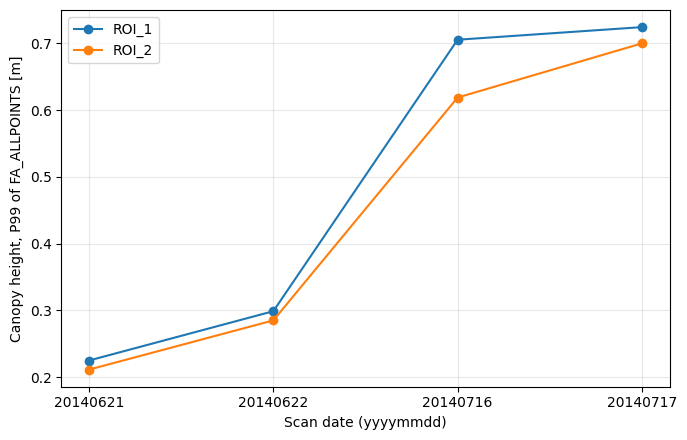

ROI_1 P99 growth: +0.499 m over the scan period (~19.2 mm/day mean)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for roi, g in df.groupby('roi'):
    g = g.sort_values('date')
    ax.plot(g['date'], g['canopy_height_P99_m'], 'o-', label=roi)
ax.set(xlabel='Scan date (yyyymmdd)', ylabel='Canopy height, P99 of FA_ALLPOINTS [m]')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig('/content/p99_timeseries.png', dpi=120); plt.show(); plt.close(fig)

g1 = df[(df.roi=='ROI_1')].dropna(subset=['canopy_height_P99_m']).sort_values('date')['canopy_height_P99_m'].values
if len(g1) >= 2:
    span_days = 26
    print(f'ROI_1 P99 growth: {g1[-1]-g1[0]:+.3f} m over the scan period '
          f'(~{(g1[-1]-g1[0])/span_days*1000:.1f} mm/day mean)')

## Step 6 — Plant height map of one scan / 植物スキャンの高さマップ
Height map of the last scan: per-pixel **maximum** relative height of plant points (the paper's
H_P uses per-pixel maxima; here shown for orientation).
/ 最終スキャンの相対高さマップ（ピクセルごと最大値）。

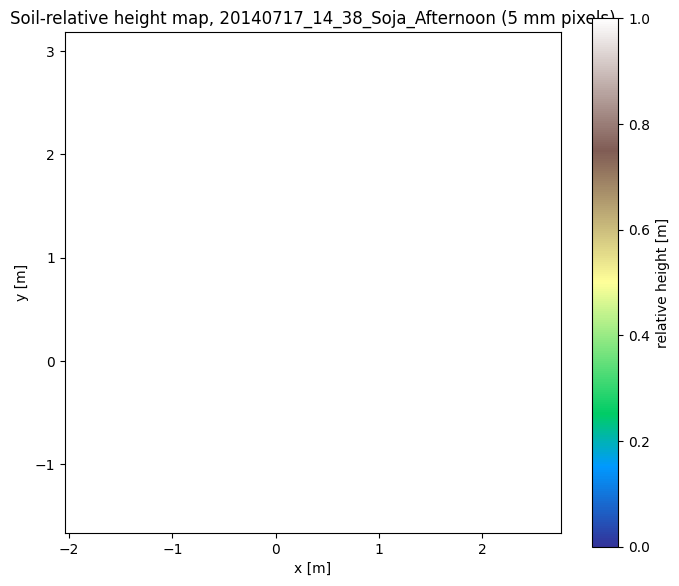

In [ ]:
pts, h = plant[SCANS[-1]]
ix = ((pts[0] - x0) / PIX).astype(int).clip(0, nx - 1)
iy = ((pts[1] - y0) / PIX).astype(int).clip(0, ny - 1)
H_P = np.full((ny, nx), np.nan)
np.maximum.at(H_P, (iy, ix), h)  # per-pixel maximum relative height

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(H_P, extent=[x0, x1, y0, y1], origin='lower', cmap='terrain', vmin=0, vmax=1.0)
ax.set(title=f'Soil-relative height map, {SCANS[-1]} ({PIX*1000:.0f} mm pixels)',
       xlabel='x [m]', ylabel='y [m]')
plt.colorbar(im, ax=ax, label='relative height [m]')
fig.tight_layout(); fig.savefig('/content/plant_height_map.png', dpi=120); plt.show(); plt.close(fig)

## Interpretation and limitations / 解釈と限界
- The pipeline follows the paper's Methods and CAHST manual literally for the reduced test scene:
  stationing → 5 mm soil height map (min-z, gap interpolation, 21 cm median filter) → soil-relative
  heights → plant points > 0.1 m → FA_ALLPOINTS percentiles (P99 = canopy height).
- The soybean canopy grows through the season; P99 per ROI increases from late June to
  mid-July 2014, qualitatively consistent with the paper's growth tracking. This **one reduced
  test scene verifies the software's principles** (readme: "only useful for a fast general check
  of the principles of the software") — it does **not** reproduce the paper's field-scale results
  (R² values, genotype comparisons, diel growth).
- Adaptations: Python (numpy/scipy) instead of compiled MATLAB; Kabsch/SVD instead of Taati's
  `estimateRigidTransform`; programmatic ROIs instead of GUI selection; PNG/CSV instead of
  xls/fig outputs. MATLAB percentiles and `numpy.percentile` both use linear interpolation.
- License: the CAHST SourceForge entry lists "Other License"; data were downloaded at runtime and
  no author binaries are redistributed here.

**References:** Friedli et al. 2016, Plant Methods 12:9 (PMCID PMC4731982) · CAHST manual
(`CAHST_Manual.pdf` in `CAHST_Software.zip`) · SourceForge `cahst4tls` (data retrieved 2026-10-03,
SHA-256 printed above) · prior research guidance: PhenoPaper investigation
`p-afc9a52f508f9e671d1286f1768c4f20-20260930T020237Z-3167965`.